CELL 1 — Import thư viện và xác định đường dẫn

In [1]:
# Import các thư viện cần dùng để kiểm tra dataset
from pathlib import Path
from collections import Counter
import random
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Vì notebook nằm trong notebooks/, project root nằm phía trên 1 cấp
PROJECT_ROOT = Path.cwd().parent

# Đường dẫn dataset
DATASET_ROOT = PROJECT_ROOT / "VR-TSD-2"
YAML_PATH = DATASET_ROOT / "data.yaml"

print("Project root :", PROJECT_ROOT)
print("Dataset root :", DATASET_ROOT)
print("data.yaml    :", YAML_PATH)
print("Dataset tồn tại:", DATASET_ROOT.exists())
print("YAML tồn tại   :", YAML_PATH.exists())

Project root : d:\Project\TrafficSignAI
Dataset root : d:\Project\TrafficSignAI\VR-TSD-2
data.yaml    : d:\Project\TrafficSignAI\VR-TSD-2\data.yaml
Dataset tồn tại: True
YAML tồn tại   : True


CELL 2 — Đọc data.yaml

In [2]:
# Đọc cấu hình dataset YOLO
with open(YAML_PATH, "r", encoding="utf-8") as file:
    data = yaml.safe_load(file)

print("Train path:", data.get("train"))
print("Val path  :", data.get("val"))
print("Test path :", data.get("test"))
print("Số class :", data.get("nc"))

print("\nDanh sách class:")
for class_id, class_name in enumerate(data["names"]):
    print(f"{class_id:2d}: {class_name}")

Train path: ../train/images
Val path  : ../valid/images
Test path : ../test/images
Số class : 58

Danh sách class:
 0: 102-cam-di-nguoc-chieu
 1: 103a-cam-oto
 2: 103b-cam-oto-re-phai
 3: 103c-cam-oto-re-trai
 4: 106-cam-oto-tai
 5: 107-cam-oto-khach-va-oto-tai
 6: 123a-cam-re-trai
 7: 123b-cam-re-phai
 8: 124a-cam-quay-dau-xe
 9: 124b-cam-oto-quay-dau-xe
10: 124c-cam-re-trai-va-cam-quay-dau-xe
11: 125-cam-vuot
12: 127-toc-do-toi-da-100
13: 127-toc-do-toi-da-20
14: 127-toc-do-toi-da-30
15: 127-toc-do-toi-da-40
16: 127-toc-do-toi-da-50
17: 127-toc-do-toi-da-60
18: 127-toc-do-toi-da-70
19: 127-toc-do-toi-da-80
20: 127-toc-do-toi-da-90
21: 128-cam-su-dung-coi
22: 130-cam-dung-va-do-xe
23: 131a-cam-do-xe
24: 131b-cam-do-xe-ngay-le
25: 131c-cam-do-xe-ngay-chan
26: 133-het-cam-vuot
27: 134-het-han-che-toc-do-toi-da
28: 135-het-tat-ca-cac-lenh-cam
29: 136-cam-di-thang
30: 137-cam-re-trai-va-re-phai
31: 201-cho-ngoat-nguy-hiem
32: 203-duong-bi-hep
33: 205-duong-giao-nhau
34: 207-giao-nhau-voi-

In [3]:
# Kiểm tra các thư mục ảnh và label của từng split
splits = ["train", "valid", "test"]

for split in splits:
    image_dir = DATASET_ROOT / split / "images"
    label_dir = DATASET_ROOT / split / "labels"

    print(f"\n===== {split.upper()} =====")
    print("Images:", image_dir)
    print("Labels:", label_dir)

    print("Images tồn tại:", image_dir.exists())
    print("Labels tồn tại:", label_dir.exists())


===== TRAIN =====
Images: d:\Project\TrafficSignAI\VR-TSD-2\train\images
Labels: d:\Project\TrafficSignAI\VR-TSD-2\train\labels
Images tồn tại: True
Labels tồn tại: True

===== VALID =====
Images: d:\Project\TrafficSignAI\VR-TSD-2\valid\images
Labels: d:\Project\TrafficSignAI\VR-TSD-2\valid\labels
Images tồn tại: True
Labels tồn tại: True

===== TEST =====
Images: d:\Project\TrafficSignAI\VR-TSD-2\test\images
Labels: d:\Project\TrafficSignAI\VR-TSD-2\test\labels
Images tồn tại: True
Labels tồn tại: True


In [4]:
# Các định dạng ảnh phổ biến cần tìm
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in splits:
    image_dir = DATASET_ROOT / split / "images"
    label_dir = DATASET_ROOT / split / "labels"

    # Lấy toàn bộ ảnh
    images = [
        path for path in image_dir.iterdir()
        if path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    # Lấy toàn bộ file label YOLO
    labels = list(label_dir.glob("*.txt"))

    print(f"\n===== {split.upper()} =====")
    print(f"Số ảnh : {len(images)}")
    print(f"Số label: {len(labels)}")


===== TRAIN =====
Số ảnh : 5668
Số label: 5668

===== VALID =====
Số ảnh : 1259
Số label: 1259

===== TEST =====
Số ảnh : 1151
Số label: 1151


Kiểm tra ảnh nào thiếu label

In [5]:
# Tìm ảnh không có file label tương ứng
for split in splits:
    image_dir = DATASET_ROOT / split / "images"
    label_dir = DATASET_ROOT / split / "labels"

    images = [
        path for path in image_dir.iterdir()
        if path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    missing_labels = []

    for image_path in images:
        label_path = label_dir / f"{image_path.stem}.txt"

        if not label_path.exists():
            missing_labels.append(image_path.name)

    print(f"\n{split}: {len(missing_labels)} ảnh không có label")

    # Chỉ hiển thị tối đa 10 file để output không quá dài
    if missing_labels:
        print(missing_labels[:10])


train: 0 ảnh không có label

valid: 0 ảnh không có label

test: 0 ảnh không có label


Kiểm tra format label YOLO

In [6]:
# Kiểm tra cấu trúc và giá trị của toàn bộ label YOLO
errors = []

for split in splits:
    label_dir = DATASET_ROOT / split / "labels"

    for label_path in label_dir.glob("*.txt"):

        with open(label_path, "r", encoding="utf-8") as file:
            lines = file.readlines()

        for line_number, line in enumerate(lines, start=1):

            parts = line.strip().split()

            # YOLO Detection phải có đúng 5 giá trị
            if len(parts) != 5:
                errors.append(
                    (split, label_path.name, line_number, "Sai số lượng giá trị")
                )
                continue

            try:
                class_id = int(parts[0])
                x_center, y_center, width, height = map(float, parts[1:])
            except ValueError:
                errors.append(
                    (split, label_path.name, line_number, "Không parse được số")
                )
                continue

            # Kiểm tra class ID
            if not (0 <= class_id < data["nc"]):
                errors.append(
                    (split, label_path.name, line_number, "Class ID không hợp lệ")
                )

            # Kiểm tra tọa độ normalized
            values = [x_center, y_center, width, height]

            if not all(0 <= value <= 1 for value in values):
                errors.append(
                    (split, label_path.name, line_number, "Bounding box ngoài khoảng 0-1")
                )

print("Tổng số lỗi label:", len(errors))

for error in errors[:20]:
    print(error)

Tổng số lỗi label: 0


In [7]:
# Đếm số bounding box của mỗi class trong từng split
class_counts = {}

for split in splits:
    counter = Counter()

    label_dir = DATASET_ROOT / split / "labels"

    for label_path in label_dir.glob("*.txt"):

        with open(label_path, "r", encoding="utf-8") as file:

            for line in file:

                parts = line.strip().split()

                if len(parts) == 5:
                    class_id = int(parts[0])
                    counter[class_id] += 1

    class_counts[split] = counter

    print(f"\n===== {split.upper()} =====")

    for class_id, class_name in enumerate(data["names"]):
        print(
            f"{class_id:2d} | "
            f"{class_name:45s} | "
            f"{counter[class_id]}"
        )


===== TRAIN =====
 0 | 102-cam-di-nguoc-chieu                        | 460
 1 | 103a-cam-oto                                  | 223
 2 | 103b-cam-oto-re-phai                          | 77
 3 | 103c-cam-oto-re-trai                          | 69
 4 | 106-cam-oto-tai                               | 196
 5 | 107-cam-oto-khach-va-oto-tai                  | 224
 6 | 123a-cam-re-trai                              | 358
 7 | 123b-cam-re-phai                              | 272
 8 | 124a-cam-quay-dau-xe                          | 113
 9 | 124b-cam-oto-quay-dau-xe                      | 148
10 | 124c-cam-re-trai-va-cam-quay-dau-xe           | 33
11 | 125-cam-vuot                                  | 92
12 | 127-toc-do-toi-da-100                         | 33
13 | 127-toc-do-toi-da-20                          | 26
14 | 127-toc-do-toi-da-30                          | 78
15 | 127-toc-do-toi-da-40                          | 65
16 | 127-toc-do-toi-da-50                          | 483
17 | 127-toc-do-toi-

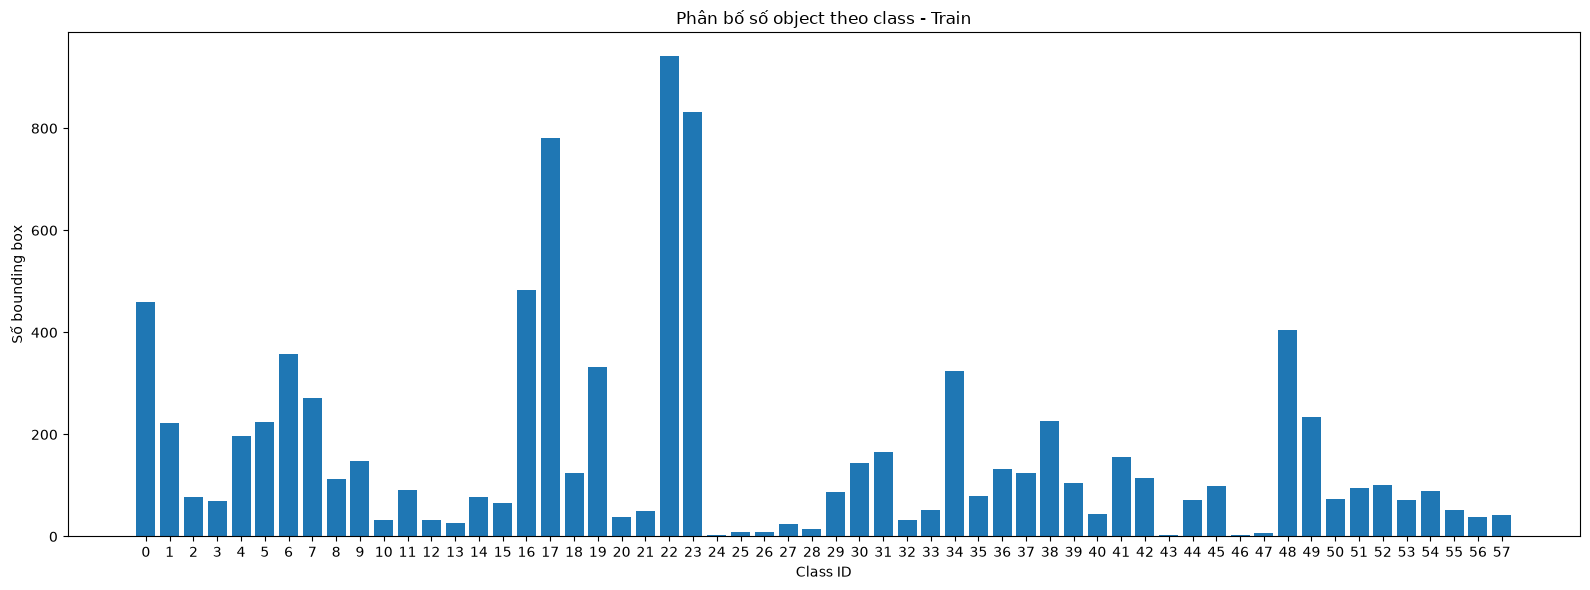

In [8]:
# Vẽ số object của từng class trong tập train
train_counts = class_counts["train"]

class_ids = list(range(data["nc"]))
counts = [train_counts[class_id] for class_id in class_ids]

plt.figure(figsize=(16, 6))

plt.bar(class_ids, counts)

plt.xlabel("Class ID")
plt.ylabel("Số bounding box")
plt.title("Phân bố số object theo class - Train")

plt.xticks(class_ids)

plt.tight_layout()
plt.show()

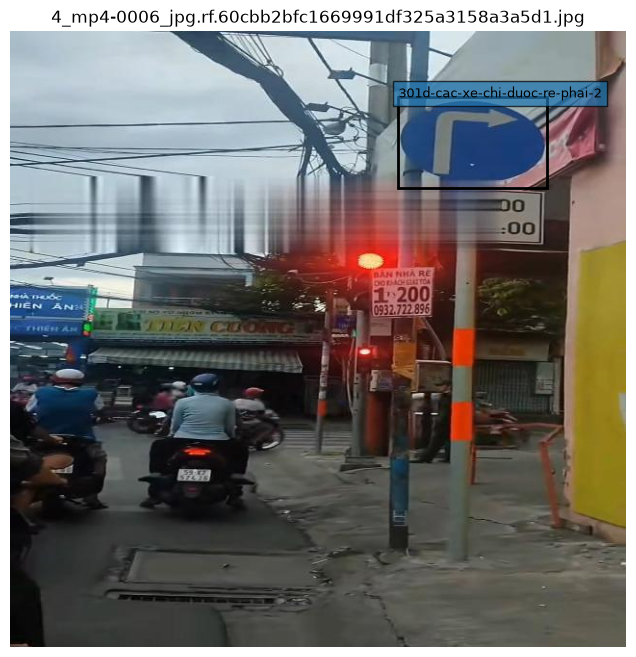

In [9]:
# Chọn ngẫu nhiên một ảnh train để kiểm tra annotation
image_dir = DATASET_ROOT / "train" / "images"
label_dir = DATASET_ROOT / "train" / "labels"

images = [
    path for path in image_dir.iterdir()
    if path.suffix.lower() in IMAGE_EXTENSIONS
]

image_path = random.choice(images)
label_path = label_dir / f"{image_path.stem}.txt"

# Đọc ảnh
image = Image.open(image_path).convert("RGB")

image_width, image_height = image.size

fig, ax = plt.subplots(figsize=(12, 8))

ax.imshow(image)

# Đọc và vẽ các bounding box
if label_path.exists():

    with open(label_path, "r", encoding="utf-8") as file:

        for line in file:

            class_id, xc, yc, bw, bh = map(float, line.split())
            class_id = int(class_id)

            # Chuyển tọa độ normalized thành pixel
            box_width = bw * image_width
            box_height = bh * image_height

            x1 = xc * image_width - box_width / 2
            y1 = yc * image_height - box_height / 2

            # Tạo bounding box
            rectangle = patches.Rectangle(
                (x1, y1),
                box_width,
                box_height,
                fill=False,
                linewidth=2
            )

            ax.add_patch(rectangle)

            # Hiển thị tên class
            ax.text(
                x1,
                y1,
                data["names"][class_id],
                fontsize=9,
                bbox=dict(alpha=0.7)
            )

ax.set_title(image_path.name)
ax.axis("off")

plt.show()